# One Component Plasma (OCP)

Oh the good ol' OCP. 
The YAML input file can be found at [input_file](https://raw.githubusercontent.com/murillo-group/sarkas/master/docs/examples/OCP/input_files/coulomb_cgs.yaml) and this notebook at [notebook](https://raw.githubusercontent.com/murillo-group/sarkas/master/docs/examples/OCP/OCP.ipynb).

In [1]:
# Import the usual libraries
import numpy as np
import matplotlib.pyplot as plt

import os
plt.style.use('MSUstyle')

import pandas as pd
import seaborn as sns

# Import sarkas
from sarkas.processes import Simulation, PostProcess, PreProcess


# Create the file path to the YAML input file
input_file_name = os.path.join('input_files', 'coulomb_cgs.yaml')

## PreProcessing

The following code is commented out since the simulation has been run before. We leave it here so that it is easy to copy and paste in your notebook.

In [2]:
# tau_p = 2.0 * np.pi /preproc.parameters.total_plasma_frequency

# tau_B = - tau_p/np.log(0.01)/preproc.parameters.dt
# gamma_L = - np.log(0.01)/(2.0 * tau_p)

# print(f'\n\nNumber of timesteps per plasma period = {tau_p/preproc.parameters.dt:.2f} [timesteps]')
# print(f'Berendsen tau = {tau_B:.2f}')
# print(f'Langevin gamma = {gamma_L:.4e} [Hertz]')

# f"{-1/(np.log(0.01)/(314*2)):.6f}"

In [3]:
# preproc = PreProcess(input_file_name)
# preproc.setup(read_yaml=True)
# preproc.run(pppm_estimate=True)

## Simulation

The following code is commented out since the simulation has been run before. 
We leave it here so that it is easy to copy and paste in your notebook.

In [4]:
# sim = Simulation(input_file_name)
# sim.setup(read_yaml=True)
# sim.run()

## PostProcessing

In [5]:
postproc = PostProcess(input_file_name, grab_last_step=True)
postproc.setup(read_yaml=True,)
# postproc.parameters.verbose = True

In [6]:
from sarkas.tools.observables import Thermodynamics

therm = Thermodynamics()
therm.setup(postproc.parameters) #, phase = "equilibration")
therm.compute()



=========================== Thermodynamics ===========================
Data saved in: 
 SarkasSimulations/OCP_cgs/PostProcessing/Thermodynamics/Production/Thermodynamics_OCP_cgs.h5
Data accessible via: self.dataframe_slices, self.dataframe

Time Series Data:
No. of blocks = 1
No. dumps per block = 125001
Total time per block: T = 2.9838e-12 [s] ~ 796 plasma periods
Time interval: dt = 2.3871e-17 [s] ~ 6.4e-03 plasma period



Thermodynamics calculation Time: 0 sec 366 msec 994 usec 340 nsec


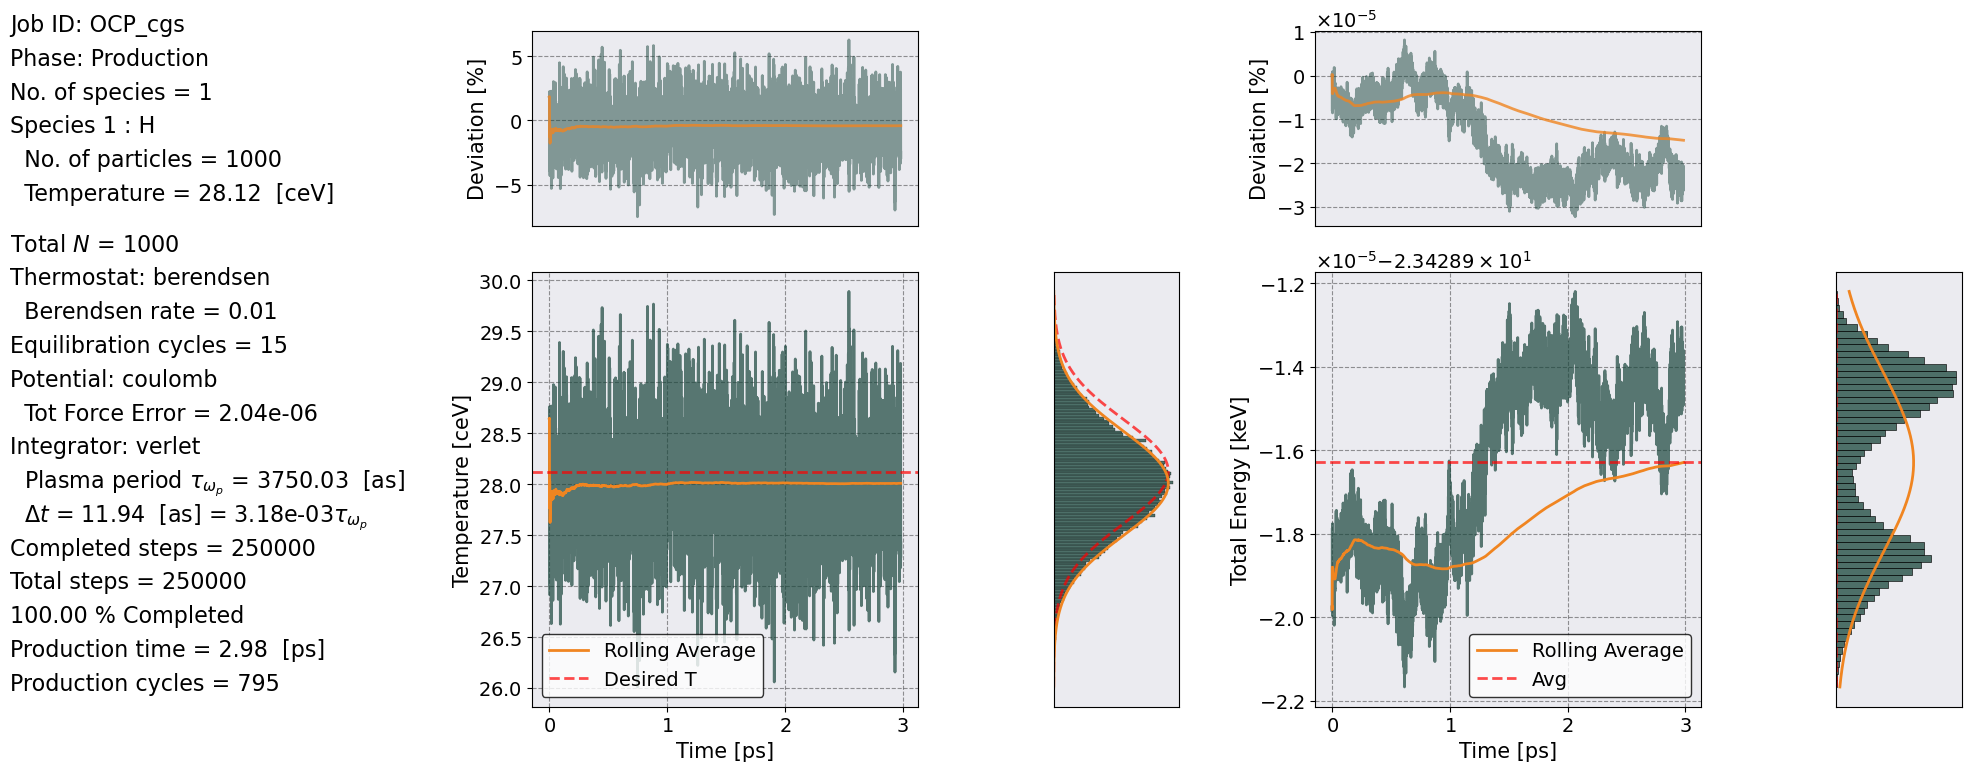

In [7]:
_ = therm.temp_energy_plot(postproc)

In [8]:
therm.dataframe.columns

MultiIndex([('Species',             'Quantity', 'Time'),
            (      'H',         'Total Energy', 'Mean'),
            (      'H',         'Total Energy',  'Std'),
            (      'H',          'Temperature', 'Mean'),
            (      'H',          'Temperature',  'Std'),
            (      'H',       'Kinetic Energy', 'Mean'),
            (      'H',       'Kinetic Energy',  'Std'),
            (      'H',     'Potential Energy', 'Mean'),
            (      'H',     'Potential Energy',  'Std'),
            (      'H',             'Pressure', 'Mean'),
            (      'H',             'Pressure',  'Std'),
            (      'H',             'Enthalpy', 'Mean'),
            (      'H',             'Enthalpy',  'Std'),
            (      'H', 'Dipole Moment Energy', 'Mean'),
            (      'H', 'Dipole Moment Energy',  'Std')],
           )

In [17]:
postproc.potential.setup(postproc.parameters, postproc.species)

In [9]:
NkT = therm.total_num_ptcls * therm.kB * therm.T_desired
nkT = therm.total_num_density * therm.kB * therm.T_desired

U = therm.dataframe[("H","Potential Energy","Mean")].mean()/ NkT
K = therm.dataframe[("H","Kinetic Energy","Mean")].mean()/ NkT

ewald_self_energy = -(postproc.particles.charges**2).sum() * postproc.potential.pppm_alpha_ewald/ (np.sqrt(np.pi) * postproc.potential.fourpie0) /NkT
background_energy = - 0.5* np.pi * postproc.particles.charges.sum()**2 / (postproc.parameters.box_volume * postproc.potential.pppm_alpha_ewald**2) / NkT

U0 = -0.895929 * 100 #  -(3/4.0 /np.pi)**(1/3)*2.888461504 * 100 
print(f"Avg Potential energy per particle: {U:.4f}")
print(f"Avg Kinetic energy per particle: {K:.4f}")
print(f"Avg Total energy per particle: {U + K:.4f}")
print(f"Ewald self-energy per particle: {ewald_self_energy:.4f}")
print(f"Background energy per particle: {background_energy:.4f}")

Avg Potential energy per particle: -84.8002
Avg Kinetic energy per particle: 1.4938
Avg Total energy per particle: -83.3063
Ewald self-energy per particle: -30.0792
Background energy per particle: -120.1669


In [22]:
from sarkas.potentials.force_pp import update as pp_update
from sarkas.potentials.force_pm import update as pm_update

u_pp, acc_pp, v_xx_pp, v_yy_pp, v_zz_pp, v_xy_pp, v_xz_pp, v_yz_pp = pp_update(postproc.particles.pos,
                                         postproc.particles.vel,
                                         postproc.particles.id,
                                         postproc.particles.masses,
                                         postproc.particles.box_lengths,
                                         postproc.potential.rc,
                                         postproc.potential.matrix,
                                         postproc.potential.force, 
                                         False, 
                                         postproc.particles.rdf_hist)

u_pm, acc_pm, v_xx, v_yy, v_zz, v_xy, v_xz, v_yz = pm_update(postproc.particles.pos,
                                      postproc.particles.charges / np.sqrt(postproc.potential.fourpie0),
                                      postproc.particles.masses,
                                      postproc.potential.pppm_mesh,
                                      postproc.potential.pppm_h_array,
                                      postproc.potential.pppm_h_volume,
                                      postproc.potential.box_volume,
                                      postproc.potential.pppm_green_function,
                                      postproc.potential.pppm_kx,
                                      postproc.potential.pppm_ky,
                                      postproc.potential.pppm_kz,
                                      postproc.potential.pppm_cao,
                                      postproc.potential.pppm_vk_xx,
                                      postproc.potential.pppm_vk_yy,
                                      postproc.potential.pppm_vk_zz,
                                      postproc.potential.pppm_vk_xy,
                                      postproc.potential.pppm_vk_xz,
                                      postproc.potential.pppm_vk_yz,
                                      postproc.potential.fftw_objects)

In [25]:
# Print the results of the potential energy and virial tensor
print(f"{'='*50} Potential Energy {'='*50}")
print(f"Short-range part of the potential: {u_pp.sum() / NkT:.4f} [kT]")
print(f"Long-range part of the potential: {u_pm.sum() / NkT:.4f} [kT]")
print(f"Ewald self-energy: {ewald_self_energy:.4f} [kT]")
print(f"Background energy: {background_energy:.4f} [kT]")
total_energy = (u_pp.sum() + u_pm.sum()) / NkT + ewald_self_energy + background_energy
print(f"Total potential energy: {total_energy:.4f} [kT]")
# print(f"Ratio of potential energies: {u_pp.sum() / u_pm.sum():.4f}")
# Calculate the total potential energy and virial tensor
print(f"{'='*50} Virial Part {'='*50}")

V_pp = (v_xx_pp + v_yy_pp + v_zz_pp + 0.0* (v_xy_pp + v_xz_pp + v_yz_pp)).sum() / NkT / 3.0
V_pm = (v_xx + v_yy + v_zz + 0.0 * (v_xy + v_xz + v_yz)).sum() / NkT / 3.0
print(f"The pp virial tensor is = {V_pp:.4f}")
print(f"The pm virial tensor is = {V_pm:.4f}")
# Calculate the excess pressure
print(f'The virial pressure is= {(V_pp + V_pm):.4f}')

# Ratio between the virial and potential energy
ratio = (V_pp + V_pm) / (total_energy)
print(f"The ratio between the virial and potential energy is = {ratio:.4f}")

================================================== Potential Energy ==================================================
Short-range part of the potential: 65.3927 [kT]
Long-range part of the potential: 0.0844 [kT]
Ewald self-energy: -30.0792 [kT]
Background energy: -120.1669 [kT]
Total potential energy: -84.7691 [kT]
================================================== Virial Part ==================================================
The pp virial tensor is = 91.9907
The pm virial tensor is = -0.0812
The virial pressure is= 91.9095
The ratio between the virial and potential energy is = -1.0842


In [18]:
from sarkas.potentials.force_pp import create_cells_array, create_head_list_arrays, particles_interaction_loop


# Total number of cells in volume
cells_per_dim, cell_lengths = create_cells_array(postproc.potential.box_lengths, postproc.potential.rc)

head, ls_array = create_head_list_arrays(postproc.particles.pos, cell_lengths, cells_per_dim)

U_s_r, acc_s_r, virial_xx, virial_yy, virial_zz, virial_xy, virial_xz, virial_yz  = particles_interaction_loop(
    postproc.particles.pos,
    postproc.particles.vel,
    postproc.particles.masses,
    postproc.particles.id,
    postproc.potential.matrix, 
    postproc.potential.rc, False,
    postproc.potential.force, 
    postproc.particles.rdf_hist, head, ls_array, cells_per_dim, postproc.potential.box_lengths
)


In [28]:
r = 2.0 * therm.a_ws
ur, fr = postproc.potential.force(r, postproc.potential.matrix[0,0])
print(f"Force: {r * fr *1000/ NkT:.4f} and potential = {ur * 1000 / NkT:.4f} [kT]")

Force: 23.7452 and potential = 5.8061 [kT]


In [ ]:
print(f'The virial pressure is= {V_pp + V_pm + ewald_self_energy/3.0 + background_energy/3.0:.4f}')

In [ ]:
rF = (sim.particles.pos * sim.particles.acc * sim.particles.masses[:, np.newaxis]) / NkT
# rF = rF.sum(axis=1).mean() / NkT    
# print(f"The force fluctuation is = {rF:.4f} [kT]")
_ = plt.hist(rF[:,:].sum(axis=1)/3.0, bins=100)
plt.ylabel('Counts')
_ = plt.xlabel(r"$\frac{1}{NkT}  \mathbf{r} \cdot \mathbf{F} $")

In [ ]:
postproc.io.h5md_filenames_tree["simulation"]["production"]

In [ ]:
from h5py import File as h5File

with h5File(postproc.io.h5md_filenames_tree["simulation"]["production"], 'r') as f:
    rF = np.zeros( (1000, 3))
    dip_en
    M = len(f['particles']['pos'])
    for i in range(M):
        rF += f['particles']['pos'][i] * f['particles']['acc'][i] 

rF *= sim.particles.masses[:, np.newaxis] / NkT / M


In [ ]:
_ = plt.hist(rF[:,:].sum(axis=1)/3.0, bins=100)
_ = plt.xlabel(r"$\frac{1}{NkT}  \langle \mathbf{r} \cdot \mathbf{F} \rangle $")

In [ ]:
from numba import jit
from sarkas.potentials.force_pp import create_cells_array, create_head_list_arrays

@jit(nopython=True)
def update_pp_2(pos, vel, p_id, p_mass, box_lengths, rc, potential_matrix, force, measure, rdf_hist):
    """
    Update the force on the particles based on a linked cell-list (LCL) algorithm.

    Parameters
    ----------
    pos: numpy.ndarray
        Particles' positions.

    vel: numpy.ndarray
        Velocity of each particle.

    p_id: numpy.ndarray
        Id of each particle

    force: func
        Potential and force values.

    potential_matrix: numpy.ndarray
        Potential parameters.

    rc: float
        Cut-off radius.

    box_lengths: numpy.ndarray
        Array of box sides' length.

    p_mass: numpy.ndarray
        Mass of each particle.


    measure : bool
        Boolean for rdf calculation.

    rdf_hist : numpy.ndarray
        Radial Distribution function array.

    Returns
    -------
    U_s_r : float
        Short-ranged component of the potential energy of the system.
    acc_s_r : numpy.ndarray
        Short-ranged component of the acceleration for the particles.
    virial_xx : numpy.ndarray
        Short-ranged component of the virial term in x-x direction.
    virial_xy : numpy.ndarray
        Short-ranged component of the virial term in x-y direction.
    virial_xz : numpy.ndarray
        Short-ranged component of the virial term in x-z direction.
    virial_yy : numpy.ndarray
        Short-ranged component of the virial term in y-y direction.
    virial_yz : numpy.ndarray
        Short-ranged component of the virial term in y-z direction.
    virial_zz : numpy.ndarray
        Short-ranged component of the virial term in z-z direction.

    Notes
    -----
    Here the "short-ranged component" refers to the Ewald decomposition of the
    short and long ranged interactions. See the wikipedia article:
    https://en.wikipedia.org/wiki/Ewald_summation or
    "Computer Simulation of Liquids by Allen and Tildesley" for more information.

    """

    # Total number of cells in volume
    cells_per_dim, cell_lengths = create_cells_array(box_lengths, rc)

    head, ls_array = create_head_list_arrays(pos, cell_lengths, cells_per_dim)

    U_s_r, acc_s_r, virial_xx, virial_yy, virial_zz, virial_xy, virial_xz, virial_yz  = particles_interaction_loop(
        pos, vel, p_mass, p_id, potential_matrix, rc, measure, force, rdf_hist, head, ls_array, cells_per_dim, box_lengths
    )

    return U_s_r, acc_s_r, virial_xx, virial_yy, virial_zz, virial_xy, virial_xz, virial_yz

@jit(nopython=True)
def particles_interaction_loop(
    pos, vel, p_mass, p_id, potential_matrix, rc, measure, force, rdf_hist, head, ls_array, cells_per_dim, box_lengths
):
    """
    Update the force on the particles based on a linked cell-list (LCL) algorithm.

    Parameters
    ----------
    pos: numpy.ndarray
        Particles' positions.

    vel: numpy.ndarray
        Particles' positions.

    p_mass: numpy.ndarray
        Mass of each particle.

    p_id: numpy.ndarray
        Id of each particle

    potential_matrix: numpy.ndarray
        Potential parameters.

    rc: float
        Cut-off radius.

    measure : bool
        Boolean for rdf calculation.

    force: func
        Potential and force values.

    rdf_hist : numpy.ndarray
        Radial Distribution function array.

    head: numpy.ndarray
        Head array of the linked cell list algorithm.

    ls_array: numpy.ndarray
        List array of the linked cell list algorithm.

    cells_per_dim: numpy.ndarray
        Number of cells per dimension.

    box_lengths: numpy.ndarray
        Array of box sides' length.

    Returns
    -------
    ptcl_pot_energy : numpy.ndarray
        Short-ranged component of the potential energy of each particle. Shape = `tot_num_ptcls`.

    acc_s_r : numpy.ndarray
        Short-ranged component of the acceleration for the particles.

    virial_species_tensor : numpy.ndarray
        Virial term of each particle. \n
        Shape = (3, 3, pos.shape[0])

    j_e : numpy.ndarray
        Energy current of each particle. Shape=((3,N)

    Notes
    -----
    Here the "short-ranged component" refers to the Ewald decomposition of the
    short and long ranged interactions. See the wikipedia article:
    https://en.wikipedia.org/wiki/Ewald_summation or
    "Computer Simulation of Liquids by Allen and Tildesley" for more information.

    """

    # Declare parameters
    rshift = np.zeros(3)  # Shifts for array flattening
    acc_s_r = np.zeros_like(pos)

    # Virial terms
    virial_xx_sr = np.zeros(pos.shape[0])
    virial_xy_sr = np.zeros(pos.shape[0])
    virial_xz_sr = np.zeros(pos.shape[0])
    virial_yy_sr = np.zeros(pos.shape[0])
    virial_yz_sr = np.zeros(pos.shape[0])
    virial_zz_sr = np.zeros(pos.shape[0])

    ptcl_pot_energy = np.zeros(pos.shape[0])  # Short-ranges potential energy of each particle
    # Pair distribution function

    rdf_nbins = rdf_hist.shape[-1]
    dr_rdf = rc / float(rdf_nbins)

    d3_min = min(cells_per_dim[2], 1)
    d3_max = max(cells_per_dim[2], 1)
    d2_min = min(cells_per_dim[1], 1)
    d2_max = max(cells_per_dim[1], 1)
    d1_min = min(cells_per_dim[0], 1)
    d1_max = max(cells_per_dim[0], 1)

    factor = 2.0 * np.pi / (3.0 * np.prod(box_lengths))


    # Dev Note: the array neighbors should be used for testing. This array is used to see if all the particles interact
    # with each other. The array is a NxN matrix initialized to empty. If two particles interact (r < rc) then the
    # matrix element (p1, p2) will be updated with p2. You can use the same array for checking if the loops go over
    # every particle in the case of small rc. If two particle see each other than the p1,p2 position is updated to -1.
    # neighbors = zeros((N, N), dtype=int64)
    # neighbors.fill(-50)

    # Loop over all cells in x, y, and z direction
    for cz in range(d3_max):
        for cy in range(d2_max):
            for cx in range(d1_max):
                # Compute the cell in 3D volume
                c = cx + cy * cells_per_dim[0] + cz * cells_per_dim[0] * cells_per_dim[1]

                # Loop over all cell pairs (N-1 and N+1)
                for cz_N in range(cz - 1, (cz + 2) * d3_min):
                    # if d3_min = 0 -> range( -1, 0). This ensures that when the z-dimension is 0 we only loop once here

                    # z cells
                    # Check periodicity: needed for 0th cell
                    # if cz_N < 0:
                    #     cz_shift = cells_per_dim[2]
                    #     rshift[2] = -box_lengths[2]
                    # # Check periodicity: needed for Nth cell
                    # elif cz_N >= cells_per_dim[2]:
                    #     cz_shift = -cells_per_dim[2]
                    #     rshift[2] = box_lengths[2]
                    # else:
                    #     cz_shift = 0
                    #     rshift[2] = 0.0
                    cz_shift = 0 + d3_max * (cz_N < 0) - cells_per_dim[2] * (cz_N >= cells_per_dim[2])
                    rshift[2] = 0.0 - box_lengths[2] * (cz_N < 0) + box_lengths[2] * (cz_N >= cells_per_dim[2])
                    # Note: In lower dimension systems (2D, 1D)
                    # cz_shift will be 1, 0, -1. This will cancel later on when cz_N + cz_shift = (-1 + 1, 0 + 0, 1 - 1)
                    # Similarly rshift[2] = 0.0 in all cases since box_lengths[2] == 0

                    for cy_N in range(cy - 1, (cy + 2) * d2_min):
                        # y cells
                        # Check periodicity
                        # if cy_N < 0:
                        #     cy_shift = cells_per_dim[1]
                        #     rshift[1] = -box_lengths[1]
                        # elif cy_N >= cells_per_dim[1]:
                        #     cy_shift = -cells_per_dim[1]
                        #     rshift[1] = box_lengths[1]
                        # else:
                        #     cy_shift = 0
                        #     rshift[1] = 0.0

                        cy_shift = 0 + d2_max * (cy_N < 0) - cells_per_dim[1] * (cy_N >= cells_per_dim[1])
                        rshift[1] = 0.0 - box_lengths[1] * (cy_N < 0) + box_lengths[1] * (cy_N >= cells_per_dim[1])

                        for cx_N in range(cx - 1, (cx + 2) * d1_min):
                            # x cells
                            # Check periodicity
                            # if cx_N < 0:
                            #     cx_shift = cells_per_dim[0]
                            #     rshift[0] = -box_lengths[0]
                            # elif cx_N >= cells_per_dim[0]:
                            #     cx_shift = -cells_per_dim[0]
                            #     rshift[0] = box_lengths[0]
                            # else:
                            #     cx_shift = 0
                            #     rshift[0] = 0.0

                            cx_shift = 0 + cells_per_dim[0] * (cx_N < 0) - cells_per_dim[0] * (cx_N >= cells_per_dim[0])
                            rshift[0] = 0.0 - box_lengths[0] * (cx_N < 0) + box_lengths[0] * (cx_N >= cells_per_dim[0])

                            # Compute the location of the N-th cell based on shifts
                            c_N = (
                                (cx_N + cx_shift)
                                + (cy_N + cy_shift) * cells_per_dim[0]
                                + (cz_N + cz_shift) * cells_per_dim[0] * cells_per_dim[1]
                            )

                            i = head[c]
                            # print(cx_N, cy_N, cz_N, "head cell", c, "p1", i)
                            # First compute interaction of head particle with neighboring cell head particles
                            # Then compute interactions of head particle within a specific cell
                            while i >= 0:

                                # Check neighboring head particle interactions
                                j = head[c_N]

                                while j >= 0:
                                    # print("cell", c, "p1", i, "cell", c_N, "p2", j)

                                    # Only compute particles beyond i-th particle (Newton's 3rd Law)
                                    if i < j:
                                        # neighbors[i, j] = -1
                                        # print("         rshift", rshift)

                                        # Compute the difference in positions for the i-th and j-th particles
                                        dx = pos[i, 0] - (pos[j, 0] + rshift[0])
                                        dy = pos[i, 1] - (pos[j, 1] + rshift[1])
                                        dz = pos[i, 2] - (pos[j, 2] + rshift[2])

                                        # Compute distance between particles i and j
                                        r = np.sqrt(dx**2 + dy**2 + dz**2)
                                        rdf_bin = int(r / dr_rdf)
                                        id_i = p_id[i]
                                        id_j = p_id[j]

                                        # These definitions are needed due to numba
                                        # see https://github.com/numba/numba/issues/5881

                                        if measure and rdf_bin < rdf_nbins:
                                            rdf_hist[id_i, id_j,rdf_bin] += 1 

                                        # If below the cutoff radius, compute the force
                                        if r < rc:
                                            p_matrix = potential_matrix[id_i, id_j]
                                            # neighbors[i, j] = j
                                            rs = p_matrix[4]
                                            # Branchless programming to avoid division by zero
                                            # Note that if rs =0.0 then the problem persist
                                            r_ij = r * (r >= rs) + rs * (r < rs)

                                            # Compute the short-ranged force
                                            pot, fr = force(r_ij, p_matrix)
                                            fr /= r_ij
                                            # Need to add the same pot to each particle pair.
                                            # The factor of 1/2 is to account for the fact that we are counting each pair twice
                                            # The total potential energy will be calculated from the sum of the potential energy of each particle (ptcls_pot_energy = ptcls.potential_energy)
                                            # The total potential energy is 1/2 * \sum_{i = 1}^N \sum_{j = 1, \\ j \neq i}^N U(r_ij)
                                            ptcl_pot_energy[i] += 0.5 * pot
                                            ptcl_pot_energy[j] += 0.5 * pot

                                            fx = dx * fr
                                            fy = dy * fr
                                            fz = dz * fr

                                            dipole_term_x = 

                                            # Update the acceleration for i particles in each dimension
                                            acc_s_r[i, 0] += fx / p_mass[i]
                                            acc_s_r[i, 1] += fy / p_mass[i]
                                            acc_s_r[i, 2] += fz / p_mass[i]

                                            # Apply Newton's 3rd law to update acceleration on j particles
                                            acc_s_r[j, 0] -= fx / p_mass[j]
                                            acc_s_r[j, 1] -= fy / p_mass[j]
                                            acc_s_r[j, 2] -= fz / p_mass[j]

                                            # Since we have the info already calculate the virial_species_tensor
                                            virial_xx_sr[i] += 0.5*dx * fx
                                            virial_xy_sr[i] += 0.5*dx * fy
                                            virial_xz_sr[i] += 0.5*dx * fz
                                            virial_yy_sr[i] += 0.5*dy * fy
                                            virial_yz_sr[i] += 0.5*dy * fz
                                            virial_zz_sr[i] += 0.5*dz * fz

                                            virial_xx_sr[j] += 0.5*dx * fx
                                            virial_xy_sr[j] += 0.5*dx * fy
                                            virial_xz_sr[j] += 0.5*dx * fz
                                            virial_yy_sr[j] += 0.5*dy * fy
                                            virial_yz_sr[j] += 0.5*dy * fz
                                            virial_zz_sr[j] += 0.5*dz * fz

                                    # Move down list (ls) of particles for cell interactions with a head particle
                                    j = ls_array[j]

                                # Check if head particle interacts with other cells
                                i = ls_array[i]

    return ptcl_pot_energy, acc_s_r, virial_xx_sr, virial_yy_sr, virial_zz_sr, virial_xy_sr, virial_xz_sr, virial_yz_sr


In [ ]:
factor= -2.0 * np.pi / (3.0 * sim.parameters.box_volume)
dipole_force = factor * (sim.particles.dipole_moment).sum(axis = 0)**2
dipole_vir_xx = dipole_force[0]
dipole_vir_yy = dipole_force[1]
dipole_vir_zz = dipole_force[2]
v_tot = V_pp + V_pm + ewald_self_energy/3.0 + background_energy/3.0 + (dipole_vir_xx + dipole_vir_yy + dipole_vir_zz).sum()/NkT / 3.0
print(f"Total dipole moment virial energy: {v_tot:.4e}")
# sim.particles.calculate_dipole_moment_energy()
# print(f"Total dipole moment energy: {sim.particles.dipole_moment_energy.sum()/NkT:.4e} [kT]")

In [ ]:
def update_2(pos, charges, masses, mesh_sizes, mesh_spacings, mesh_volume, box_volume, G_k, kx_v, ky_v, kz_v, cao, vg0, vg1, vg2, vg3, vg4, vg5, fft_objects):
    """
    Calculate the long range part of particles' accelerations using the Particle-Mesh method.

    This function implements the core of the Particle-Mesh (PM) component of the PPPM algorithm.
    It computes the long-range contributions to particle accelerations and potential energies.

    Parameters
    ----------
    pos : ndarray
        Particles' positions, shape (N, 3).
    charges : ndarray
        Particles' charges, shape (N,).
    masses : ndarray
        Particles' masses, shape (N,).
    mesh_sizes : ndarray
        Number of mesh points per direction, shape (3,).
    mesh_spacings : ndarray
        Width of the mesh cells, shape (3,).
    mesh_volume : float
        Volume of a single mesh cell.
    box_volume : float
        Total volume of the simulation box.
    G_k : ndarray
        Optimized Green's function in Fourier space, shape (mesh_sizes[2], mesh_sizes[1], mesh_sizes[0]).
    kx_v : ndarray
        Array of kx values, shape (1, mesh_sizes[0]).
    ky_v : ndarray
        Array of ky values, shape (mesh_sizes[1], 1).
    kz_v : ndarray
        Array of kz values, shape (mesh_sizes[2], 1, 1).
    cao : ndarray
        Charge assignment order for each direction, shape (3,).
    vg0, vg1, vg2, vg3, vg4, vg5 : ndarray
        Virial coefficient fields corresponding to V_xx, V_yy, V_zz, V_xy, V_xz, V_yz, shape (mesh_sizes[2], mesh_sizes[1], mesh_sizes[0]).
    fft_objects : FFTWObjects
        Pre-created FFT objects for reuse across timesteps

    Returns
    -------
    pot_particle : ndarray
        Long range part of the potential for each particle, shape (N,).
    acc_f : ndarray
        Long range part of particles' accelerations, shape (N, 3).

    Notes
    -----
    This function uses FFTW through pyfftw for efficient Fourier transforms. It assumes
    periodic boundary conditions and requires pre-computed optimized Green's function.

    The algorithm follows these main steps:
    1. Assign charges to the mesh
    2. Perform forward FFT on the charge density
    3. Solve Poisson's equation in Fourier space
    4. Compute the electric field in Fourier space
    5. Perform inverse FFT to get real-space electric field
    6. Interpolate mesh values to particle positions

    The function is optimized using Numba's JIT compilation.

    """

    # Calculate the necessary shifts
    mid, pshift = mesh_point_shift(cao)
    
    # Calculate particles' position relative to the mesh points
    mesh_pos, mesh_points = calc_mesh_coord(pos, mesh_spacings, cao)
    
    # Calculate charge density on mesh
    rho_r = calc_charge_dens(mesh_pos, mesh_points, charges, cao, mesh_sizes, mid, pshift)
    
    # Allocate memory for the output arrays of the FFT
    rho_k = empty_aligned((mesh_sizes[2], mesh_sizes[1], mesh_sizes[0]), dtype=complex)
    E_x = empty_aligned((mesh_sizes[2], mesh_sizes[1], mesh_sizes[0]), dtype=complex)
    E_y = empty_aligned((mesh_sizes[2], mesh_sizes[1], mesh_sizes[0]), dtype=complex)
    E_z = empty_aligned((mesh_sizes[2], mesh_sizes[1], mesh_sizes[0]), dtype=complex)
    phi_r = empty_aligned((mesh_sizes[2], mesh_sizes[1], mesh_sizes[0]), dtype=complex)
    virial_r_xx = empty_aligned((mesh_sizes[2], mesh_sizes[1], mesh_sizes[0]), dtype=complex)
    virial_r_yy = empty_aligned((mesh_sizes[2], mesh_sizes[1], mesh_sizes[0]), dtype=complex)
    virial_r_zz = empty_aligned((mesh_sizes[2], mesh_sizes[1], mesh_sizes[0]), dtype=complex)
    virial_r_xy = empty_aligned((mesh_sizes[2], mesh_sizes[1], mesh_sizes[0]), dtype=complex)
    virial_r_xz = empty_aligned((mesh_sizes[2], mesh_sizes[1], mesh_sizes[0]), dtype=complex)
    virial_r_yz = empty_aligned((mesh_sizes[2], mesh_sizes[1], mesh_sizes[0]), dtype=complex)

    # Use reusable FFT object
    fft_objects.forward_transform(rho_r, rho_k)

    # Shift the DC value at the center of the ndarray
    rho_k = fftshift(rho_k)
    
    # Potential from Poisson eq.
    phi_k = G_k * rho_k
    
    # Calculate the Electric field's components on the mesh
    E_kx, E_ky, E_kz = calc_field(phi_k, kx_v, ky_v, kz_v)
    
    # Prepare for IFFT and compute - using reusable objects
    fft_objects.backward_transform(ifftshift(E_kx), E_x)
    fft_objects.backward_transform(ifftshift(E_ky), E_y)
    fft_objects.backward_transform(ifftshift(E_kz), E_z)

    # FFT normalization
    E_x /= mesh_volume
    E_y /= mesh_volume
    E_z /= mesh_volume
    
    # Calculate the potential energy of each particle
    fft_objects.backward_transform(ifftshift(phi_k), phi_r)
    phi_r /= mesh_volume

    # Virial tensor components - all using the same reusable IFFT
    fft_objects.backward_transform(ifftshift(phi_k * vg0), virial_r_xx)
    virial_r_xx /= mesh_volume

    fft_objects.backward_transform(ifftshift(phi_k * vg1), virial_r_yy)
    virial_r_yy /= mesh_volume

    fft_objects.backward_transform(ifftshift(phi_k * vg2), virial_r_zz)
    virial_r_zz /= mesh_volume

    fft_objects.backward_transform(ifftshift(phi_k * vg3), virial_r_xy)
    virial_r_xy /= mesh_volume

    fft_objects.backward_transform(ifftshift(phi_k * vg4), virial_r_xz)
    virial_r_xz /= mesh_volume

    fft_objects.backward_transform(ifftshift(phi_k * vg5), virial_r_yz)
    virial_r_yz /= mesh_volume

    # Interpolate all the fields to the particles
    acc_f, pot_particle, virial_xx, virial_yy, virial_zz, virial_xy, virial_xz, virial_yz = \
        calc_pm_all(
            E_x.real, E_y.real, E_z.real,
            phi_r.real,
            virial_r_xx.real, virial_r_yy.real, virial_r_zz.real, virial_r_xy.real, virial_r_xz.real, virial_r_yz.real,
            mesh_pos, mesh_points,
            charges, masses,
            cao, mesh_sizes, mid, pshift
        )

    return pot_particle, acc_f, virial_xx, virial_yy, virial_zz, virial_xy, virial_xz, virial_yz


In [ ]:
from numba import jit
from sarkas.potentials.force_pm import assgnmnt_func
from numpy import zeros_like

from sarkas.potentials.force_pm import mesh_point_shift, calc_mesh_coord, calc_charge_dens, calc_field
from pyfftw import empty_aligned
from numpy.fft import fftshift, ifftshift   

@jit(nopython=True)
def calc_pot_pm(phi_r, mesh_pos, mesh_points, charges, cao, mesh_sz, mid, pshift):
    """
    Calculates the long range part of particles' potential energies.

    Parameters
    ----------
    phi_r : numpy.ndarray
        Potential energy at mesh points.

    mesh_pos: numpy.ndarray
        Particles' positions relative to the mesh.

    mesh_points: numpy.ndarray
        Particles' positions on the mesh.

    charges : numpy.ndarray
        Particles' charges.

    cao : int
        Charge assignment order.

    mesh_sz: numpy.ndarray
        Mesh points per direction.

    mid: numpy.ndarray
        Midpoint flag for the three directions.

    pshift: numpy.ndarray
        Midpoint shift in each direction.

    Returns
    -------
    pot_p : numpy.ndarray
          Potential energy of each particle.

    """
    pot_p = zeros_like(charges)  # potential energy for each particle

    for ipart, q in enumerate(charges):
        ix = mesh_points[ipart, 0]
        x = mesh_pos[ipart, 0] - (ix + mid[0])

        iy = mesh_points[ipart, 1]
        y = mesh_pos[ipart, 1] - (iy + mid[1])

        iz = mesh_points[ipart, 2]
        z = mesh_pos[ipart, 2] - (iz + mid[2])

        wx = assgnmnt_func(cao[0], x)
        wy = assgnmnt_func(cao[1], y)
        wz = assgnmnt_func(cao[2], z)

        # Use modulo for periodic boundary conditions - consistent with calc_charge_dens
        base_z = (iz - pshift[2]) % mesh_sz[2]
        base_y = (iy - pshift[1]) % mesh_sz[1]
        base_x = (ix - pshift[0]) % mesh_sz[0]

        for g in range(cao[2]):
            r_g = (base_z + g) % mesh_sz[2]
            
            for i in range(cao[1]):
                r_i = (base_y + i) % mesh_sz[1]
                
                for j in range(cao[0]):
                    r_j = (base_x + j) % mesh_sz[0]

                    pot_p[ipart] += 0.5 * q * phi_r[r_g, r_i, r_j] * wz[g] * wy[i] * wx[j]

    return pot_p

@jit(nopython=True)
def calc_pm_all(E_x_r, E_y_r, E_z_r,
                phi_r,
                vg0, vg1, vg2, vg3, vg4, vg5,
                mesh_pos, mesh_points,
                charges, masses,
                cao, mesh_sz, mid, pshift):
    """
    Interpolate the electric field, potential energy, and virial coefficients to each particle.

    Parameters
    ----------
    E_x_r : ndarray
        Electric field in x-direction at mesh points, shape (mesh_sz[2], mesh_sz[1], mesh_sz[0]).
    E_y_r : ndarray
        Electric field in y-direction at mesh points, shape (mesh_sz[2], mesh_sz[1], mesh_sz[0]).
    E_z_r : ndarray
        Electric field in z-direction at mesh points, shape (mesh_sz[2], mesh_sz[1], mesh_sz[0]).
    phi_r : ndarray
        Potential energy at mesh points, shape (mesh_sz[2], mesh_sz[1], mesh_sz[0]).
    mesh_pos : ndarray
        Particles' positions relative to the mesh, shape (N, 3).
    mesh_points : ndarray
        Particles' positions on the mesh, shape (N, 3).
    charges : ndarray
        Particles' charges, shape (N,).
    masses : ndarray
        Particles' masses, shape (N,).
    cao : ndarray
        Charge assignment order for each direction, shape (3,).
    mesh_sz : ndarray
        Number of mesh points per direction, shape (3,).
    mid : ndarray
        Midpoint flag for the three directions, shape (3,).
    pshift : ndarray
        Midpoint shift in each direction, shape (3,).
    
    Returns
    -------
    acc : ndarray
        Particle accelerations, shape (N, 3).
    pot : ndarray
        Particle potential energies, shape (N,).
    virial_xx : ndarray
        Virial xx components, shape (N,).
    virial_yy : ndarray
        Virial yy components, shape (N,).
    virial_zz : ndarray
        Virial zz components, shape (N,).
    virial_xy : ndarray
        Virial xy components, shape (N,).
    virial_xz : ndarray
        Virial xz components, shape (N,).
    virial_yz : ndarray
        Virial yz components, shape (N,).
    """

    N = charges.shape[0]
    acc = zeros_like(mesh_pos)  # Particle accelerations, shape (N, 3)
    pot = zeros_like(charges)
    q_over_m = charges / masses

    virial_xx = zeros_like(charges)
    virial_yy = zeros_like(charges)
    virial_zz = zeros_like(charges)
    virial_xy = zeros_like(charges)
    virial_xz = zeros_like(charges)
    virial_yz = zeros_like(charges)

    for ipart in range(N):
        ix = mesh_points[ipart, 0]
        x = mesh_pos[ipart, 0] - (ix + mid[0])

        iy = mesh_points[ipart, 1]
        y = mesh_pos[ipart, 1] - (iy + mid[1])

        iz = mesh_points[ipart, 2]
        z = mesh_pos[ipart, 2] - (iz + mid[2])

        wx = assgnmnt_func(cao[0], x)
        wy = assgnmnt_func(cao[1], y)
        wz = assgnmnt_func(cao[2], z)

        q = charges[ipart]
        q_m = q_over_m[ipart]

        # Use modulo for periodic boundary conditions - consistent with calc_charge_dens
        base_z = (iz - pshift[2]) % mesh_sz[2]
        base_y = (iy - pshift[1]) % mesh_sz[1]
        base_x = (ix - pshift[0]) % mesh_sz[0]

        for g in range(cao[2]):
            r_g = (base_z + g) % mesh_sz[2]
            
            for i in range(cao[1]):
                r_i = (base_y + i) % mesh_sz[1]
                
                for j in range(cao[0]):
                    r_j = (base_x + j) % mesh_sz[0]

                    weight = wz[g] * wy[i] * wx[j]

                    # Acceleration
                    acc[ipart, 0] += q_m * E_x_r[r_g, r_i, r_j] * weight
                    acc[ipart, 1] += q_m * E_y_r[r_g, r_i, r_j] * weight
                    acc[ipart, 2] += q_m * E_z_r[r_g, r_i, r_j] * weight

                    # Potential energy
                    pot[ipart] += 0.5 * q * phi_r[r_g, r_i, r_j] * weight

                    # Virial components
                    virial_xx[ipart] += 0.5 * q * vg0[r_g, r_i, r_j] * weight
                    virial_yy[ipart] += 0.5 * q * vg1[r_g, r_i, r_j] * weight
                    virial_zz[ipart] += 0.5 * q * vg2[r_g, r_i, r_j] * weight
                    virial_xy[ipart] += 0.5 * q * vg3[r_g, r_i, r_j] * weight
                    virial_xz[ipart] += 0.5 * q * vg4[r_g, r_i, r_j] * weight
                    virial_yz[ipart] += 0.5 * q * vg5[r_g, r_i, r_j] * weight

    return acc, pot, virial_xx, virial_yy, virial_zz, virial_xy, virial_xz, virial_yz


In [ ]:

cao = postproc.potential.pppm_cao
mesh_spacings = postproc.potential.pppm_h_array
mesh_sizes = postproc.potential.pppm_mesh
mesh_volume = postproc.potential.pppm_h_volume
charges = postproc.particles.charges / np.sqrt(postproc.potential.fourpie0)
masses = postproc.particles.masses
pos = postproc.particles.pos
fft_objects = postproc.potential.fftw_objects
vg0 = postproc.potential.pppm_vk_xx
vg1 = postproc.potential.pppm_vk_yy
vg2 = postproc.potential.pppm_vk_zz
vg3 = postproc.potential.pppm_vk_xy
vg4 = postproc.potential.pppm_vk_xz
vg5 = postproc.potential.pppm_vk_yz

kx_v = postproc.potential.pppm_kx
ky_v = postproc.potential.pppm_ky
kz_v = postproc.potential.pppm_kz
G_k = postproc.potential.pppm_green_function

box_volume = postproc.parameters.box_volume
L = postproc.parameters.box_lengths[0]  # Assuming cubic box, L is the length of one side
# Calculate the necessary shifts
mid, pshift = mesh_point_shift(cao)

# Calculate particles' position relative to the mesh points
mesh_pos, mesh_points = calc_mesh_coord(pos, mesh_spacings, cao)

# Calculate charge density on mesh
rho_r = calc_charge_dens(mesh_pos, mesh_points, charges, cao, mesh_sizes, mid, pshift)

# Allocate memory for the output arrays of the FFT
rho_k = empty_aligned((mesh_sizes[2], mesh_sizes[1], mesh_sizes[0]), dtype=complex)
E_x = empty_aligned((mesh_sizes[2], mesh_sizes[1], mesh_sizes[0]), dtype=complex)
E_y = empty_aligned((mesh_sizes[2], mesh_sizes[1], mesh_sizes[0]), dtype=complex)
E_z = empty_aligned((mesh_sizes[2], mesh_sizes[1], mesh_sizes[0]), dtype=complex)
phi_r = empty_aligned((mesh_sizes[2], mesh_sizes[1], mesh_sizes[0]), dtype=complex)
virial_r_xx = empty_aligned((mesh_sizes[2], mesh_sizes[1], mesh_sizes[0]), dtype=complex)
virial_r_yy = empty_aligned((mesh_sizes[2], mesh_sizes[1], mesh_sizes[0]), dtype=complex)
virial_r_zz = empty_aligned((mesh_sizes[2], mesh_sizes[1], mesh_sizes[0]), dtype=complex)
virial_r_xy = empty_aligned((mesh_sizes[2], mesh_sizes[1], mesh_sizes[0]), dtype=complex)
virial_r_xz = empty_aligned((mesh_sizes[2], mesh_sizes[1], mesh_sizes[0]), dtype=complex)
virial_r_yz = empty_aligned((mesh_sizes[2], mesh_sizes[1], mesh_sizes[0]), dtype=complex)

# Use reusable FFT object
fft_objects.forward_transform(rho_r, rho_k)

# Shift the DC value at the center of the ndarray
rho_k = fftshift(rho_k)

rho_k_real = rho_k.real
rho_k_imag = rho_k.imag
rho_k_sq = rho_k_real * rho_k_real + rho_k_imag * rho_k_imag

# Potential from Poisson eq.
phi_k = G_k * rho_k

# # Calculate the potential energy of each particle
fft_objects.backward_transform(ifftshift(phi_k), phi_r)
phi_r /= mesh_volume

# Plot phi_r
fig, ax = plt.subplots(figsize=(10, 8))
p1 = ax.imshow(phi_r[0].real, origin='lower', extent=[0, L, 0, L], cmap='viridis')
plt.colorbar(p1, label=r"$\phi(x,y)$", pad=0.02)
ax.scatter(pos[:, 0], pos[:, 1], s=10, marker="o", c='black', label="Particles")
ax.grid(False)
ax.set(xlabel=r"x", ylabel=r"y", title=r"Potential field $\phi(x,y,z = 0)$")
plt.tight_layout()

# # Potential of each particle
pot_particle = calc_pot_pm(phi_r.real, mesh_pos, mesh_points, charges, cao, mesh_sizes, mid, pshift)
U_p1 = pot_particle.sum()

# Total potential energy
U_f = 0.5 * (rho_k_sq * G_k).sum() / box_volume

# Calculate the Electric field's components on the mesh
E_kx, E_ky, E_kz = calc_field(phi_k, kx_v, ky_v, kz_v)

# Prepare for IFFT and compute - using reusable objects
fft_objects.backward_transform(ifftshift(E_kx), E_x)
fft_objects.backward_transform(ifftshift(E_ky), E_y)
fft_objects.backward_transform(ifftshift(E_kz), E_z)

# FFT normalization
E_x /= mesh_volume
E_y /= mesh_volume
E_z /= mesh_volume

# Virial tensor components - all using the same reusable IFFT
fft_objects.backward_transform(ifftshift(phi_k * vg0), virial_r_xx)
virial_r_xx /= mesh_volume

fft_objects.backward_transform(ifftshift(phi_k * vg1), virial_r_yy)
virial_r_yy /= mesh_volume

fft_objects.backward_transform(ifftshift(phi_k * vg2), virial_r_zz)
virial_r_zz /= mesh_volume

fft_objects.backward_transform(ifftshift(phi_k * vg3), virial_r_xy)
virial_r_xy /= mesh_volume

fft_objects.backward_transform(ifftshift(phi_k * vg4), virial_r_xz)
virial_r_xz /= mesh_volume

fft_objects.backward_transform(ifftshift(phi_k * vg5), virial_r_yz)
virial_r_yz /= mesh_volume

# Interpolate all the fields to the particles
acc_f, pot_particle, virial_xx, virial_yy, virial_zz, virial_xy, virial_xz, virial_yz = \
    calc_pm_all(
        E_x.real, E_y.real, E_z.real,
        phi_r.real,
        virial_r_xx.real, virial_r_yy.real, virial_r_zz.real, virial_r_xy.real, virial_r_xz.real, virial_r_yz.real,
        mesh_pos, mesh_points,
        charges, masses,
        cao, mesh_sizes, mid, pshift
    )
print(pot_particle.shape)
# Total potential energy of the particles
U_p = pot_particle.sum()

# Compare
print(f"Total potential energy from FFT: {U_p* therm.beta/ 10_000:.4e}")
print(f"Total potential energy from particles: {U_p1 * therm.beta/10_000:.4e}")
print(f"Error: {np.abs(1 - U_p/U_f):.4e}")


In [ ]:
# Calculate the memory cost of 10 3D arrays with size = postproc.potential.pppm_mesh and complex dtype
mesh_size = 4*postproc.potential.pppm_mesh

cost = np.zeros(mesh_size, dtype=complex).nbytes / 1024**2

print(f"Memory cost for 10 3D arrays with size {mesh_size} and complex dtype: {10*cost:.2f} [MB]")

## Radial Distribution Function

In [ ]:
from sarkas.tools.observables import RadialDistributionFunction

rdf = RadialDistributionFunction()
rdf.setup(postproc.parameters)
rdf.compute()

In [ ]:
_ = rdf.plot(
    scaling = rdf.a_ws, 
    y = ('H-H RDF', 'Mean'),
    xlabel = r'$r /a_{ws}$',
    ylabel = r"$g(r)$",
    legend = False
)

Calculate the Pressure from the RDF

In [ ]:
from sarkas.tools.observables import PressureTensor

pt = PressureTensor()
pt.setup(postproc.parameters)
pt.compute()
pt.compute_acf()

## Pressure from RDF

In order to check that our code are correct, let's verify some laws. 

The pressure of the system is calculated from $\mathcal P(t)= \frac1{3} {\rm Tr} \overleftrightarrow{\mathcal P}(t)$ and also from 

\begin{equation}
P = n k_BT - \frac{2\pi}{3} n^2 \int_0^{\infty} dr \, r^3 g(r) \frac{d\phi(r)}{dr} 
\end{equation}

where $g(r)= 1 + h(r)$ is the pair distribution function that we have already calculated. In YOCP case we can calculate the Hartree term and obtain

\begin{equation}
P = n k_BT - \frac{2\pi}{3} n^2 \int_0^{\infty} dr \, r^3 h(r) \frac{d\phi(r)}{dr} 
\end{equation}

Let's now calculate the pressure from the integral of the RDF. This is obtained from the method `compute_from_rdf` of the `Thermodynamics` object. 

Looking at the documentation of this [method](../../api/tools_subpckg/Thermodynamics_methods/sarkas.tools.observables.Thermodynamics.compute_from_rdf.rst) we notice that it returns five values:
the Hartree and correlational terms between species $A$ and $B$ and the ideal pressure $n k_BT$. 

The total pressure is given from the sum of the three terms and should be equal to the 

$$ P = n k_BT + P_{\rm Corr} = {\operatorname {Mean} } \left \{ \mathcal P(t) \right \} $$

In [ ]:
therm.beta_slices = np.array(therm.beta)
NkT =  postproc.parameters.total_num_ptcls / therm.beta 
nkT = NkT/therm.box_volume
_, u_h, u_c, p_h, p_c = therm.compute_from_rdf(rdf, postproc.potential)
print(f"The excess energy per particle is = {u_c[0] / NkT :.4f} [kT]")
print(f'The excess pressure per particle is = {(p_h[0] + p_c[0] ) / nkT :.4f} [kT]')

In [ ]:
U0

In [ ]:
# Let's plot it
t_wp = pt.plasma_period

p_id = nkT
ax = pt.plot( 
    scaling = (t_wp, p_id),
    y = ("Total","Pressure", "Mean"),
    xlabel = "Plasma cycles",
    ylabel = r"$ P(t)/nkT$"
       )
ax.plot(
    pt.dataframe[("Total", "Quantity", 'Time')]/t_wp,
    pt.dataframe[("Total",'Pressure','Mean')].expanding().mean()/p_id )
ax.legend(['Pressure', 'Cumulative Avg'])

In [ ]:
PV = pt.dataframe[("Total","Pressure", "Mean")].mean() / nkT  + ewald_self_energy/3.0 + background_energy/3.0
U = therm.dataframe[("H", "Potential Energy", "Mean")].mean()/ NkT
print(f'The ratio between pressure and internal energy is: {PV:.4f}')

In [ ]:
from sarkas.tools.observables import make_gaussian_plot
pressure = pt.dataframe[("Total",'Pressure Tensor XX','Mean')] + pt.dataframe[("Total",'Pressure Tensor YY','Mean')]  +  pt.dataframe[("Total",'Pressure Tensor ZZ','Mean')]
pressure /= 3.0* nkT
pressure += + ewald_self_energy/3.0 + background_energy/3.0
fig, axes = make_gaussian_plot(
    time = pt.dataframe[("Total", "Quantity", 'Time')]/t_wp,
    data = pressure,
    xlabel = 'Plasma periods',
    ylabel = r"$ \beta P(t)/n$"
)

In [ ]:
# Diagonal terms
column_zzzz = [
    ('Pressure Tensor ACF XXXX', 'Mean'),
    ('Pressure Tensor ACF YYYY', 'Mean'),
    ('Pressure Tensor ACF ZZZZ', 'Mean'),
]
J_zzzz_0 = pt.dataframe_acf[column_zzzz].iloc[0].mean()
    
# Cross-Diagonal Terms
column_zzxx = [
    ('Pressure Tensor ACF XXYY', 'Mean'),
    ('Pressure Tensor ACF XXZZ', 'Mean'),
    ('Pressure Tensor ACF YYZZ', 'Mean')
]
J_zzxx_0 = pt.dataframe_acf[column_zzxx].iloc[0].mean()
    
# Cross Off Diagonal terms
column_xyxy = [
    ('Pressure Tensor ACF XYXY', 'Mean'),
    ('Pressure Tensor ACF XZXZ', 'Mean'),
    ('Pressure Tensor ACF YZYZ', 'Mean')
]
J_xyxy_0 = pt.dataframe_acf[column_xyxy].iloc[0].mean()

# The units of J's are [Density *  Energy]^2
condition = (J_zzzz_0 - J_zzxx_0)/(2.0 * J_xyxy_0)
msg = f'The isotropy condition : (J_zzzz_0 - J_zzxx_0 )/( 2*J_xyxy_0 ) = {condition:.4f}'
print(msg)

cross_off = pt.dataframe_acf[column_xyxy].mean(axis = 1)
cross_off /= cross_off.iloc[0]

t_wp = 2.0*np.pi/ pt.total_plasma_frequency
ax = pt.plot(scaling = t_wp, 
             y = column_xyxy,
             acf = True,
             xlabel = "Plasma periods",
             ls = '--',
             marker = 'o',
             label = [r"$\langle P_{xy}(\tau)P_{xy}(0)\rangle$ ACF", r"$\langle P_{xz}(\tau)P_{xz}(0)\rangle$ ACF", r"$\langle P_{yz}(\tau)P_{yz}(0)\rangle$ ACF"]
         )
ax.set(xscale = 'symlog')
time_col = pt.dataframe_acf.columns[0]
ax.plot( pt.dataframe_acf[time_col]/t_wp, cross_off, ls = ':', label = "Average")
_ = ax.legend()
# fig = ax.figure
# fig.savefig( os.path.join(pic_fldr,"Pxy_ACF_plot.png") )

In [ ]:
J_xyxy_0 / (NkT**2/ 1000) # / (pt.species_masses[0]*(pt.a_ws * pt.total_plasma_frequency)**2)**2

In [ ]:
# Calculate the elastic constants from the integrals of g(r)
# sigma_zzzz, sigma_zzxx, sigma_xyxy = pt.sum_rule(therm.beta_slices.mean(), rdf, postproc.potential)

hartrees, corrs = rdf.compute_sum_rule_integrals(postproc.potential)
# Eq. 2.3.43 -44 in Boon and Yip
I_1 = 0.0*hartrees[:, 1].sum() + corrs[:, 1].sum()
I_2 = 0.0*hartrees[:, 2].sum() + corrs[:, 2].sum()

sigma_zzzz = 3.0 * nkT + 2.0 / 15.0 * I_1 + I_2 / 5.0
sigma_zzxx = nkT - 2.0 / 5.0 * I_1 + I_2 / 15.0
sigma_xyxy = nkT + 4.0 / 15.0 * I_1 + I_2 / 15.0

print(f"{sigma_zzzz:.3e}, {sigma_zzxx:.3e}, {sigma_xyxy:.3e}")


In [ ]:
# Shear modulus
G_inf = J_xyxy_0*therm.beta_slices.mean()*pt.box_volume
K_inf = 1.0/3.0*(J_zzzz_0 + 2.0* J_zzxx_0)*therm.beta_slices.mean()*pt.box_volume

K_sr = (sigma_zzzz + 2.0*sigma_zzxx)/3.0

print("G_inf = {:.3e}, sum_rule = {:.3e}, ratio = {:.4f}".format( G_inf, sigma_xyxy, abs(sigma_xyxy) /G_inf) )
print("K_inf = {:.3e}, sum_rule = {:.3e}, ratio = {:.2f}".format( K_inf,  K_sr, K_sr /K_inf) )

In [ ]:
from scipy.integrate import cumulative_trapezoid

acfs = (pt.dataframe_acf[column_xyxy]/pt.dataframe_acf[column_xyxy].iloc[0]).values
corr_times = 2.0 * cumulative_trapezoid(acfs**2, x = pt.dataframe_acf.iloc[:,0] / pt.plasma_period, axis = 0)
fig, ax = plt.subplots(1,1)
ax.plot(pt.dataframe_acf.iloc[:-1,0]/pt.plasma_period,corr_times[:,0], label = 'XY')
ax.plot(pt.dataframe_acf.iloc[:-1,0]/pt.plasma_period,corr_times[:,1], label = 'XZ')
ax.plot(pt.dataframe_acf.iloc[:-1,0]/pt.plasma_period,corr_times[:,2], label = 'YZ')
ax.set(xlabel = 'Plasma Periods', ylabel = 'Correlation time', xscale = 'symlog', ylim = (0, 2))
ax.legend()

In [ ]:
acf_df = pt.calc_better_acf_data(plasma_periods_shift = 10)
acf_df.info()

In [ ]:
# Plot
acf_0 = acf_df["Stress ACF Mean"].iloc[0]
fig, ax = plt.subplots(1,1)
ax.plot(acf_df["Time"]/t_wp, acf_df["Stress ACF Mean"]/acf_0)
ax.fill_between(acf_df["Time"]/t_wp, 
                acf_df["Stress ACF Mean"]/acf_0 - acf_df["Stress ACF Std"]/acf_0,
               acf_df["Stress ACF Mean"]/acf_0 + acf_df["Stress ACF Std"]/acf_0,
               alpha = 0.3)
ax.set(xscale= 'log', ylim = (-0.1, 1.1))

## Viscosity

The shear viscosity is calculated from the Green-Kubo relation

\begin{equation}
\eta = \frac{\beta V}{3} \sum_{\alpha} \sum_{\gamma \neq \alpha} \int_0^{\infty} dt \, \left \langle \delta\mathcal P_{\alpha\gamma}(t) \delta \mathcal P_{\alpha\gamma}(0) \right \rangle,
\end{equation}

where $\beta = 1/k_B T$, $\alpha,\gamma = {x, y, z}$ and $\delta \mathcal P_{\alpha\gamma}(t) = \mathcal P_{\alpha\gamma}(t) - \left \langle \mathcal P_{\alpha\gamma} \right \rangle_t$.

The bulk viscosity is given by a similar relation

\begin{equation}
\eta_V = \beta V \int_0^{\infty}dt \,  \left \langle \delta \mathcal P(t) \delta \mathcal P(0) \right \rangle,
\end{equation}

where $\delta \mathcal P(t) = \mathcal P(t) - \left \langle \mathcal P  \right \rangle_t$ is the fluctuation of the scalar pressure.

In [ ]:
from scipy.integrate import cumulative_trapezoid

eta_t = therm.beta_slices.mean() * pt.box_volume * cumulative_trapezoid(acf_df.iloc[:,1], x = acf_df.iloc[:, 0])

In [ ]:
time_rescaled = acf_df.iloc[1:,0] / pt.plasma_period
eta_rescale_const = pt.total_plasma_frequency * pt.a_ws**2 * pt.species_masses[0] * pt.total_num_density


fig, ax = plt.subplots(1,1)
ax.plot(time_rescaled,
        eta_t/eta_rescale_const,
       label = r'$\eta$')
ax.legend()
ax.set(xlabel = r'Plasma periods lag',
      ylabel = r"Shear viscosity $\eta$",
      xscale=  'log',
        ylim = (0, 0.19)
      )


## Dynamic Structure Factor

In [ ]:
from sarkas.tools.observables import DynamicStructureFactor

dsf = DynamicStructureFactor()
dsf.max_ka_value = 10
dsf.angle_averaging = 'principal_axis'
dsf.no_slices = 4
dsf.setup(postproc.parameters)
dsf.compute()

In [ ]:
# dsf.parse()

In [ ]:
dsf.dataframe.columns

In [ ]:
ax = dsf.plot(scaling = dsf.total_plasma_frequency, 
         y = [("H-H","Mean", "ka1 = 0.3898"), ("H-H","Mean", "ka3 = 1.1693"), ("H-H","Mean", "ka5 = 1.9489")],
         xlabel = r'$\omega/\omega_p$',
         xlim = (-2.5, 2.5),
        logy = True)
ax.legend()

### Collective Mode Dispersion

In [ ]:
import matplotlib as mpl

w = dsf.dataframe[(" "," ","Frequencies")]/ dsf.total_plasma_frequency

ka_mesh, w_mesh = np.meshgrid(dsf.ka_values, w)

Skw = dsf.dataframe[("H-H", "Mean")]
fig, ax = plt.subplots(1,1)
pc = ax.pcolormesh(ka_mesh, w_mesh, Skw,
                   shading = 'auto',
                   norm = mpl.colors.LogNorm(vmin = 1e-22, vmax = 1e-15),
                   cmap='plasma')
ax.set(ylim = (0,3),
       xlim = (0,8),
       xlabel = r'$ka$', 
       ylabel = r'$\omega/\omega_p$')
plt.colorbar(pc)

In [ ]:
from sarkas.tools.observables import CurrentCorrelationFunction

ccf = CurrentCorrelationFunction()
ccf.max_ka_value = 10
ccf.angle_averaging = 'principal_axis'
ccf.no_slices = 4
ccf.setup(postproc.parameters)
ccf.pretty_print()

In [ ]:
# ccf.compute()
ccf.parse()

In [ ]:
ccf.dataframe

In [ ]:
w = dsf.dataframe[(" "," ","Frequencies")]/ ccf.total_plasma_frequency

ka_mesh, w_mesh = np.meshgrid(dsf.ka_values, w)

Lkw = ccf.dataframe[("Longitudinal", "H-H", "Mean")]
fig, ax = plt.subplots(1,1)
pc = ax.pcolormesh(ka_mesh, w_mesh, Lkw,
                   shading = 'auto',
                   norm = mpl.colors.LogNorm(vmin = 0.5e10, vmax = 0.5e15),
                   cmap='nipy_spectral')
ax.set(ylim = (0,3),
       xlim = (0,8),
       xlabel = r'$ka$', 
       ylabel = r'$\omega/\omega_p$')
plt.colorbar(pc)

In [ ]:
w = dsf.dataframe[(" "," ","Frequencies")]/ ccf.total_plasma_frequency

ka_mesh, w_mesh = np.meshgrid(dsf.ka_values, w)

Lkw = ccf.dataframe[("Transverse", "H-H", "Mean")]
fig, ax = plt.subplots(1,1)
pc = ax.pcolormesh(ka_mesh, w_mesh, Lkw,
                   shading = 'auto',
                   norm = mpl.colors.LogNorm(vmin = 3e9, vmax = 3e14),
                   cmap='nipy_spectral')
ax.set(ylim = (0,3),
       xlim = (0,8),
       xlabel = r'$ka$', 
       ylabel = r'$\omega/\omega_p$')
plt.colorbar(pc)

## Diffusion

Diffusion is calculated from the integral of the velocity autocorrelation function, $\left \langle \bar{\mathbf v} (t) \cdot \bar{\mathbf v}(0) \right \rangle$,

\begin{equation}
D = \frac{1}{3} \int_0^{\tau} dt \, \left \langle \bar{\mathbf v} (t) \cdot \bar{\mathbf v}(0) \right \rangle
\end{equation}

where $\bar{\mathbf v}$ is the particle-averaged velocity.

In [ ]:
from sarkas.tools.observables import VelocityAutoCorrelationFunction
from sarkas.tools.transport import Diffusion

In [ ]:
vacf = VelocityAutoCorrelationFunction()
vacf.setup(postproc.parameters, no_slices=10)
vacf.compute_acf()

In [ ]:
diff = Diffusion()
diff.setup(postproc.parameters, vacf, therm)
diff.compute(vacf)

In [ ]:
rescaling = 1.0/vacf.total_plasma_frequency/vacf.a_ws**2
fig, ax = plt.subplots(1,1, figsize=(10,7))
ax.plot(tc.diffusion_df["Time"].iloc[:,0]*vacf.total_plasma_frequency, 
        tc.diffusion_df[("H Diffusion","Mean")] * rescaling,
       label = r'Diffusion')

ax.plot(tc.diffusion_df["Time"].iloc[:,0]*vacf.total_plasma_frequency, 
        tc.diffusion_df[("H Diffusion","Mean")].expanding().mean() * rescaling,
        ls = '--', label = r'Mov Avg')

ax.legend(ncol = 2)
ax.set(xlabel = r"$\tau \omega_p$",ylabel = r" $D/a^2 \omega_p$")